# Customer Segmentation Analysis – Online Retail Data

## Objective

This notebook continues the customer analysis we began in SQL, where we performed data cleaning and explored key business questions from the Online Retail dataset.  
Here, our goal is to take that work further — exploring customer behavior in Python, identifying useful behavioral features,  
and segmenting customers into meaningful groups that can help the business understand and engage with different types of buyers.

## About the Dataset
The data comes from the **Online Retail Dataset (UCI Machine Learning Repository)**,  
which records all transactions from a UK-based online store between **2010 and 2011**.  
Each row represents a single invoice line item and includes:

- `Invoice` – transaction ID  
- `StockCode` – product identifier  
- `Description` – product name  
- `Quantity` – number of items purchased per transaction  
- `InvoiceDate` – timestamp of the transaction  
- `Price` – unit price of each product  
- `CustomerID` – unique customer identifier  
- `Country` – customer’s country of residence  

During SQL preprocessing:
- We added an **`is_return`** column to quickly identify and filter out returned orders.  
- Removed entries with **missing CustomerID**, as they cannot be used for customer-level analysis.  
- Performed initial cleaning and summarization to ensure the data was consistent and ready for behavioral segmentation.

This notebook builds on that foundation — summarizing customer-level metrics, exploring their distributions,  
and preparing the data for clustering to uncover distinct customer segments.


## 1. Importing Dependencies

Before exploring the dataset, we load essential Python libraries for data analysis and visualization.  
These libraries will help us clean the data, summarize customer behavior, and eventually segment customers.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## 2. Loading the Dataset

The dataset contains individual transactions from an online retail business.  
At this stage, our goal is simply to get familiar with the structure of the data — not to analyze behavior yet.


In [3]:
load_dotenv()  # loads the .env file

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT", "5432")
database = os.getenv("DB_NAME")

# Build PostgreSQL connection string
connection_string = f"postgresql://{user}:{password}@{host}:{port}/{database}"

# Create SQLAlchemy engine
engine = create_engine(connection_string)

# Define SQL query
query = "SELECT * FROM retail_customers;"

# Read SQL query result into DataFrame
customer = pd.read_sql(query, engine)

sales = pd.read_csv("retail_sales.csv", dtype={0: str})

In [4]:
# sales['']

In [ ]:
print(customer.shape)

(794086, 10)


## 3. Understanding Data Structure

We check:
- Number of records
- Column data types
- Presence of duplicates
- Basic descriptive statistics

This helps verify that the dataset is clean and ready for deeper analysis.

In [6]:
# ----------------------------------------------
# 1. DATA TYPE CLEANING & CONVERSION
# ----------------------------------------------

type_mapping = {
    "invoice": str,
    "stockcode": str,
    "description": str,
    "quantity": int,
    "price": float,
    "customerid": str,
    "country": str,
    "totalamount": float,
    "is_return": int
}

customer = customer.astype(type_mapping)
customer["invoicedate"] = pd.to_datetime(customer["invoicedate"])

# ----------------------------------------------
# 2. FORMATTED OUTPUT BLOCK
# ----------------------------------------------

from io import StringIO

print("\n# DATA OVERVIEW")
print("=" * 60)

# 1. Number of Records
print("\n## 1. Dataset Dimensions")
print("-" * 60)
print(f"Total Rows: **{customer.shape[0]:,}**")
print(f"Total Columns: **{customer.shape[1]}**")

# 2. Column Data Types
# print("\n## 2. Column Data Types")
# print("-" * 60)

# # buffer = StringIO()
# # customer.info(buf=buffer, memory_usage="deep")
# # info_output = buffer.getvalue()
# # print(info_output)

print("\n## 2. Column Data Types (Post-Conversion)")
print("-" * 60)
customer_info = customer.info( memory_usage="deep")

# 3. Duplicate Check
print("\n## 3. Duplicate Check")
print("-" * 60)

has_duplicates = customer.duplicated().any()
print(f"Any Duplicate Rows? **{has_duplicates}**")

if has_duplicates:
    print(f"Number of Duplicate Rows: **{customer.duplicated().sum():,}**")

# 4. Descriptive Statistics
print("\n## 4. Summary Statistics")
print("-" * 60)
display(customer.describe().T.style.set_caption("Descriptive Statistics"))

# 5. Top Rows by Total Amount
print("\n## 5. Top Transactions (Descending by Total Amount)")
print("-" * 60)
display(
    customer
        .sort_values("totalamount", ascending=False)
        .head(10)
        .style.set_caption("Top Rows by Total Amount")
)



# DATA OVERVIEW

## 1. Dataset Dimensions
------------------------------------------------------------
Total Rows: **794,086**
Total Columns: **10**

## 2. Column Data Types (Post-Conversion)
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794086 entries, 0 to 794085
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoice      794086 non-null  object        
 1   stockcode    794086 non-null  object        
 2   description  794086 non-null  object        
 3   quantity     794086 non-null  int32         
 4   invoicedate  794086 non-null  datetime64[ns]
 5   price        794086 non-null  float64       
 6   customerid   794086 non-null  object        
 7   country      794086 non-null  object        
 8   totalamount  794086 non-null  float64       
 9   is_return    794086 non-null  int32         
dtypes: datetime64[ns](1), float64(

,count,mean,min,25%,50%,75%,max,std
quantity,794086.000000,12.636373,-80995.000000,2.000000,5.000000,12.000000,80995.000000,191.578454
invoicedate,794086,2011-01-02 12:15:59.311661568,2009-12-01 07:45:00,2010-07-02 09:46:00,2010-12-02 12:09:00,2011-07-31 15:31:00,2011-12-09 12:50:00,nan
price,794086.000000,2.970226,0.030000,1.250000,1.950000,3.750000,649.500000,4.473684
totalamount,794086.000000,20.599038,-168469.600000,4.350000,11.700000,19.500000,168469.600000,305.892942
is_return,794086.000000,0.022146,0.000000,0.000000,0.000000,0.000000,1.000000,0.147159



## 5. Top Transactions (Descending by Total Amount)
------------------------------------------------------------


,invoice,stockcode,description,quantity,invoicedate,price,customerid,country,totalamount,is_return
776039,581483,23843,"Paper Craft , Little Birdie",80995,2011-12-09 09:15:00,2.080000,16446,United Kingdom,168469.600000,0
421804,541431,23166,Medium Ceramic Top Storage Jar,74215,2011-01-18 10:01:00,1.040000,12346,United Kingdom,77183.600000,0
538381,556444,22502,Picnic Basket Wicker 60 Pieces,60,2011-06-10 15:28:00,649.500000,15098,United Kingdom,38970.000000,0
332012,530715,84347,Rotating Silver Angels T-Light Hldr,9360,2010-11-04 11:36:00,1.690000,15838,United Kingdom,15818.400000,0
169270,511465,15044A,Pink Paper Parasol,3500,2010-06-08 12:59:00,2.550000,18008,United Kingdom,8925.000000,0
630448,567423,23243,Set Of Tea Coffee Sugar Tins Pantry,1412,2011-09-20 11:05:00,5.060000,17450,United Kingdom,7144.720000,0
417498,540815,21108,Fairy Cake Flannel Assorted Colour,3114,2011-01-11 12:55:00,2.100000,15749,United Kingdom,6539.400000,0
493185,550461,21108,Fairy Cake Flannel Assorted Colour,3114,2011-04-18 13:20:00,2.100000,15749,United Kingdom,6539.400000,0
289758,525968,84347,Rotating Silver Angels T-Light Hldr,3120,2010-10-08 10:10:00,1.660000,15838,United Kingdom,5179.200000,0
688788,573003,23084,Rabbit Night Light,2400,2011-10-27 12:11:00,2.080000,14646,Netherlands,4992.000000,0


### Observations

- Some transactions have **very high total amounts**.
- These are caused by **large purchase quantities**, not errors.
- Negative quantities exist because returns are recorded in the same dataset.
  - This is expected behavior in retail data (not data corruption).
- Therefore, high-value transactions should be kept — they represent bulk buyers.
---

## 4. Distribution of Transaction-Level Variables

Before summarizing data at the customer level, we examine how quantity, price, and transaction amount vary.

This helps us understand:
- Whether most customers buy similarly,
- or if a few customers contribute disproportionately (a common pattern in retail).

The histograms and boxplot below confirm **right-skewed distributions**, meaning a small number of large purchases as outliers influence total revenue.


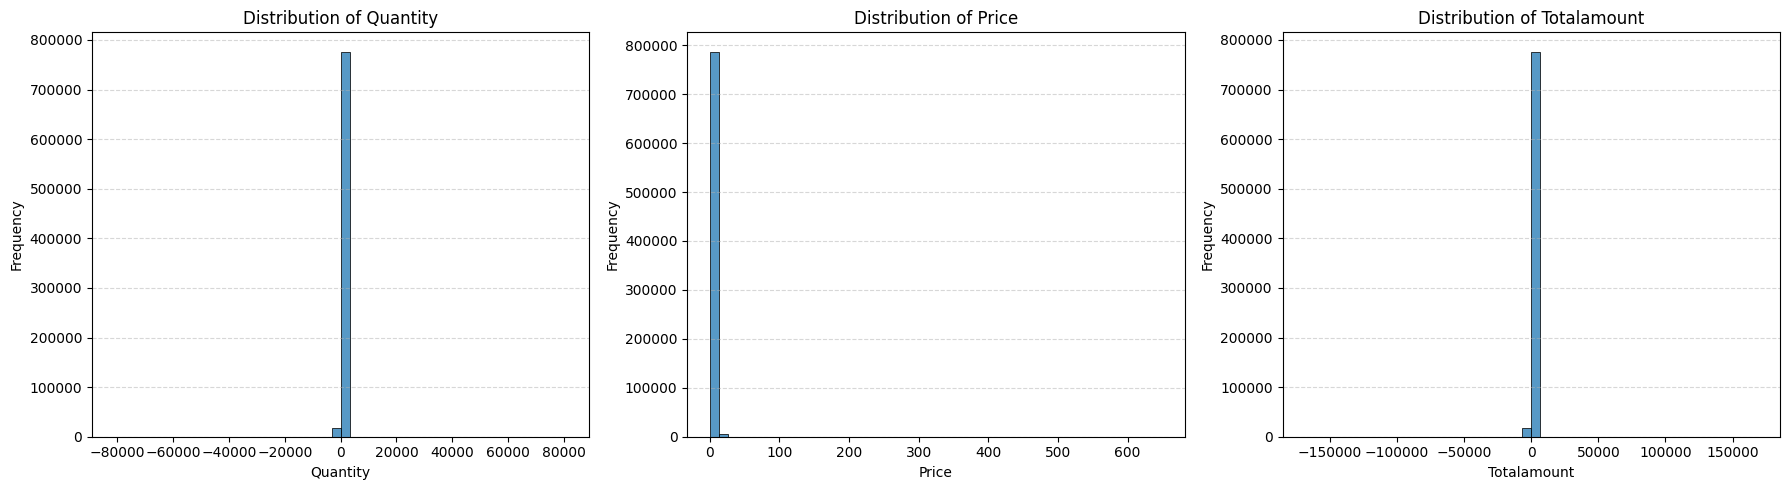

In [16]:
plot_cols = ['quantity', 'price', 'totalamount']

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) 

for i, col in enumerate(plot_cols):
    
    sns.histplot(data=customer, x=col, bins=50, ax=axes[i], kde=False, edgecolor='black')
    
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

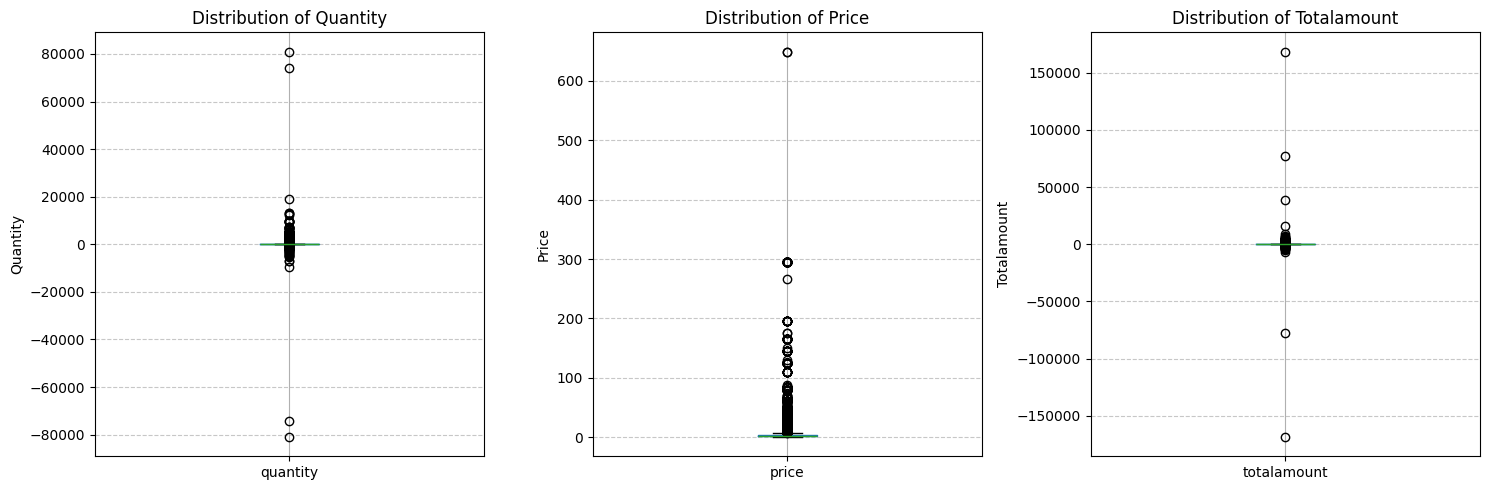

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5)) 

axes = axes.flatten() 

# Iterate through the columns and plot each one
for i, col in enumerate(plot_cols):
    # Plot the boxplot on the specific axis
    customer.boxplot(column=col, ax=axes[i])
    
    # Set titles and labels
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_ylabel(col.capitalize())
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to prevent titles from overlapping
plt.tight_layout()
plt.show()


---


## 5. Why Transaction-Level Analysis Is Not Enough

The patterns we observed so far describe **individual transactions**, not **the customers themselves**.

However, the business decisions we want to make — such as who to retain, who to re-engage, or who to encourage to buy more — are **customer-level decisions**.

So instead of analyzing each purchase separately, we now summarize the historical behavior of each customer.  

This allows us to answer meaningful questions like:
- How recently has each customer purchased?
- How much have they spent overall?
- How frequently do they place orders?
- Do they usually buy small amounts or in bulk?

By converting transaction data into **customer-level features**, we set the foundation for meaningful segmentation.


In [19]:
# Set analysis snapshot date (1 day after last invoice)
snapshot_date = customer['invoicedate'].max() + pd.Timedelta(days=1)

# Filter out return transactions
non_returns = customer[customer['is_return'] == 0].copy()

# Calculate customer-level metrics: recency, spend, order count, total quantity
customer_metrics = (
    non_returns.groupby("customerid")
    .agg(
        recency=('invoicedate', lambda x: (snapshot_date - x.max()).days),  # Days since last purchase
        total_spent=("totalamount", "sum"),         # Lifetime spend
        total_orders=("invoice", "nunique"),        # Unique purchase count
        total_quantity=("quantity", "sum"),         # Items bought
    )
)

# Compute average quantity per order
customer_metrics['average_quantity'] = customer_metrics['total_quantity'] / customer_metrics['total_orders']

# Display top customers by spend
display(customer_metrics.sort_values('total_spent', ascending=False).head())


,recency,total_spent,total_orders,total_quantity,average_quantity
customerid,,,,,
18102,1,580987.04,145,181645,1252.724138
14646,2,526751.52,145,367072,2531.531034
14156,10,303069.88,144,164281,1140.840278
14911,1,272252.79,373,147804,396.257373
17450,8,244784.25,51,83914,1645.372549


### Interpretation of Customer-Level Features

These new features describe different aspects of customer engagement:

| Feature | Meaning |
|--------|---------|
| **Recency** | Lower values mean more recent purchases (more active customers) |
| **Total Orders** | How often the customer buys |
| **Total Spend** | Overall monetary value of the customer |
| **Average Quantity** | Indicates whether the customer usually buys in small or large batches |

These metrics will form the basis of our segmentation — they represent **customer behavior**, not just sales activity.

---

## 6. Exploring Customer-Level Metrics

Before applying clustering, we need to understand how our customer-level features behave.

Clustering algorithms like K-Means assume that features are normally distributed and on a similar scale.  
So, in this section, we'll explore:

- The distribution of each feature  
- Relationships between features  
- Potential skewness or outliers  

This will help us decide if transformations or scaling are needed before modeling.


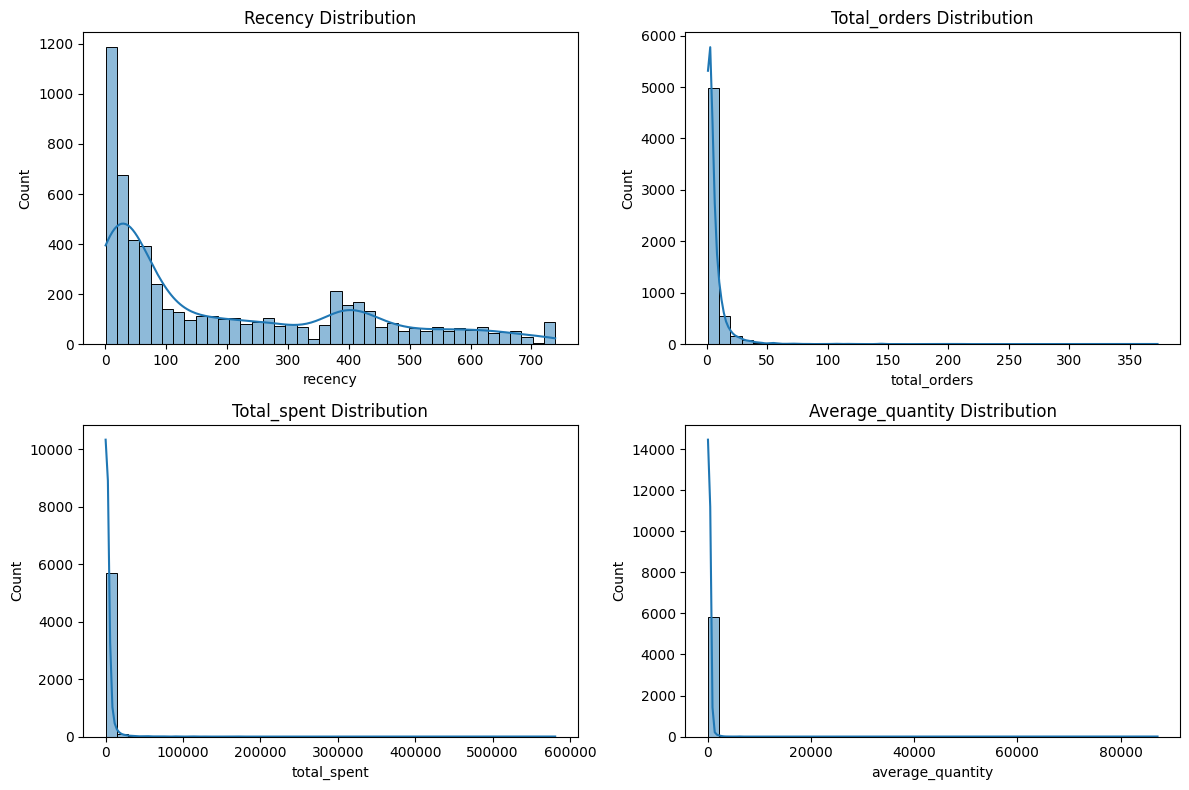

In [20]:
# Visualize distribution of each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ['recency', 'total_orders', 'total_spent', 'average_quantity']

for ax, col in zip(axes.flat, cols):
    sns.histplot(customer_metrics[col], kde=True, ax=ax, bins=40)
    ax.set_title(f'{col.capitalize()} Distribution')
plt.tight_layout()
plt.show()


### Observations on Customer-Level Distributions

The distributions reveal a strong imbalance across all behavioral metrics:

- **Recency:** Most customers have purchased very recently, while a smaller group hasn’t purchased for several hundred days. This long right tail suggests a few inactive customers.
- **Total Orders:** A large majority of customers have placed only a few orders, but there are some very frequent buyers.
- **Total Spend:** Spending behavior is extremely skewed — most customers spend small amounts, while a few contribute a huge portion of total revenue.
- **Average Quantity:** Similar to spending, most customers buy in small quantities, but there are some bulk purchasers that distort the scale.

Overall, the data is **highly right-skewed** across all metrics.  
Such imbalance can cause clustering algorithms to give more weight to large-value customers and ignore subtle patterns in the majority group.

To handle this, we’ll apply transformations to **reduce skewness** and **scale all features** so that each contributes equally to distance-based clustering.

---

## 7. Making the Features Consistent — Recency to Freshness

In our dataset, **Recency** represents the number of days since a customer's last purchase.  
A smaller value means a *more active* customer, while a larger value means an *inactive* one.

However, all other features — such as **Total Orders**, **Total Spend**, and **Average Quantity** — follow the opposite logic,  
where *higher values* indicate *greater engagement or value*.

To make the interpretation consistent across features and help the clustering algorithm learn meaningful patterns,  
we convert **Recency** into **Freshness**:

$$
\text{freshness} = \text{max(recency)} - \text{recency}
$$

Now, a **higher Freshness value** means a customer purchased more recently.


In [21]:
# Convert Recency to Freshness
customer_metrics['freshness'] = customer_metrics['recency'].max() - customer_metrics['recency']

# Drop recency
customer_metrics.drop(columns='recency', inplace=True)

# Preview updated dataset
display(customer_metrics.head())

,total_spent,total_orders,total_quantity,average_quantity,freshness
customerid,,,,,
12346,77352.96,3,74239,24746.333333,413
12347,4921.53,8,2967,370.875000,737
12348,1658.40,5,2704,540.800000,664
12349,3678.69,3,1621,540.333333,720
12350,294.40,1,196,196.000000,429


---

## 8. Feature Transformation and Scaling

The customer-level data contains large numerical ranges and heavy right skewness across multiple columns.  
Clustering algorithms like **K-Means** or **K-Medoids** rely on Euclidean distances,  
so skewed or unscaled features can dominate the model and distort cluster formation.

To address this:
1. We’ll reduce skewness using the **Yeo–Johnson transformation** — preferred here because it’s numerically stable and works well even if future data includes zeros.  
2. Then, we’ll normalize all features using **StandardScaler** so that each has mean = 0 and standard deviation = 1.


In [ ]:
# Select features for clustering
features = ['freshness', 'total_orders', 'total_spent', 'average_quantity']

# Apply Yeo–Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
customer_metrics_yj = customer_metrics.copy()
customer_metrics_yj[features] = pt.fit_transform(customer_metrics_yj[features])

# Scale features
scaler = StandardScaler()
customer_scaled = scaler.fit_transform(customer_metrics_yj[features])

# Convert back to DataFrame for clarity
customer_scaled_df = pd.DataFrame(customer_scaled, columns=features, index=customer_metrics_yj.index)

customer_scaled_df.describe(percentiles=[0.99, 0.999])


,freshness,total_orders,total_spent,average_quantity
count,5.852000e+03,5.852000e+03,5.852000e+03,5.852000e+03
mean,-1.942701e-17,3.156888e-17,2.428376e-17,1.942701e-17
std,1.000085e+00,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.033210e+00,-1.264585e+00,-4.604597e+00,-4.492889e+00
50%,4.699706e-01,-1.113906e-02,-2.104261e-04,1.748407e-02
99%,1.044419e+00,2.015693e+00,2.320803e+00,2.567372e+00
99.9%,1.044419e+00,2.366820e+00,3.348672e+00,4.600007e+00
max,1.044419e+00,2.504544e+00,3.971224e+00,8.163743e+00


---

## 9. Visualizing Transformed Features

After applying the **Yeo–Johnson** transformation and **Standard Scaling**,  
we’ll check whether the skewness has reduced and if the features are now more balanced for clustering.

If the transformation worked well:
- The histograms should look roughly symmetrical.  
- Most values should be centered around zero due to standardization.


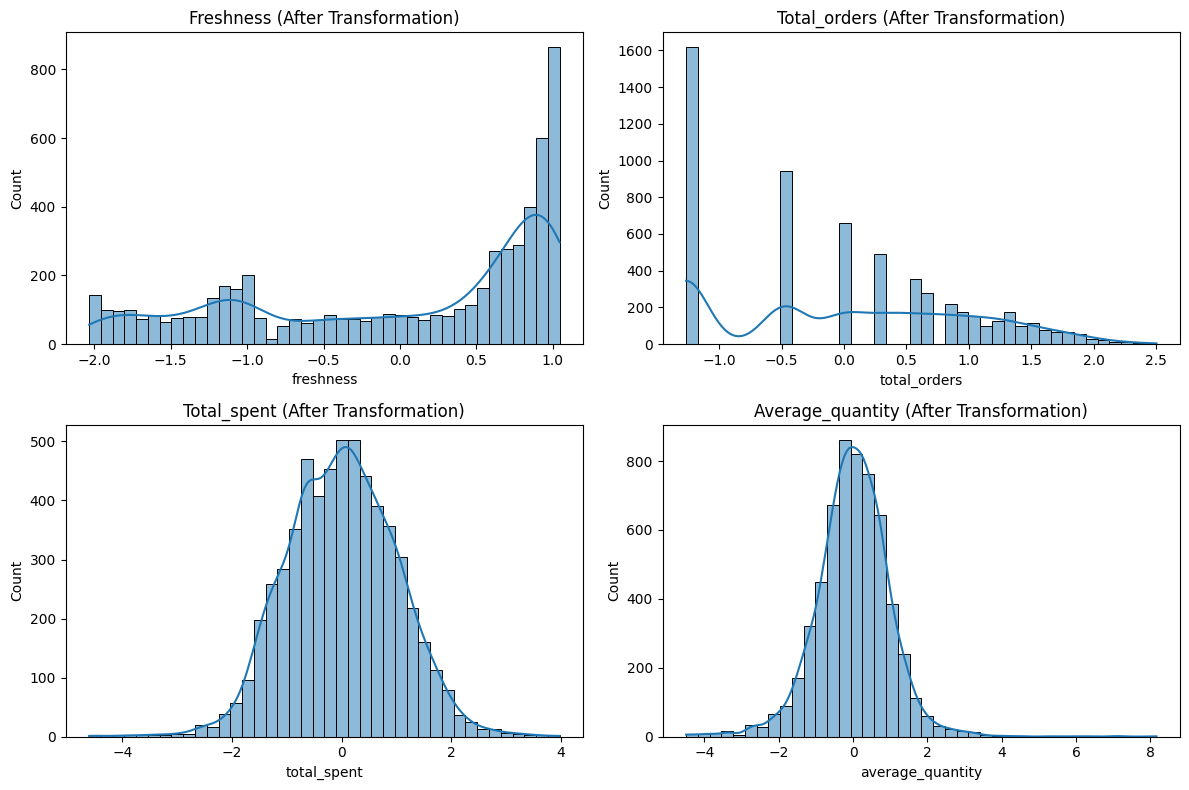

In [25]:
# Visualize transformed feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ['freshness', 'total_orders', 'total_spent', 'average_quantity']

for ax, col in zip(axes.flat, cols):
    sns.histplot(customer_scaled_df[col], kde=True, bins=40, ax=ax)
    ax.set_title(f'{col.capitalize()} (After Transformation)')
plt.tight_layout()
plt.show()


In [26]:
# Clip extreme values in scaled average_quantity
clip_limits = customer_scaled_df['average_quantity'].quantile(0.999)
customer_scaled_df['average_quantity'] = np.clip(
    customer_scaled_df['average_quantity'], 
    a_min=None, 
    a_max=clip_limits
)

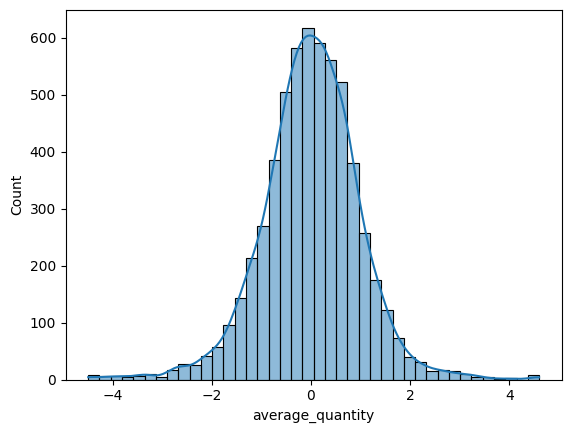

In [27]:
# Plotting avg_quantity after clipping
sns.histplot(customer_scaled_df, x="average_quantity", kde=True, bins=40)
plt.show()

### Observations

- **Freshness:** The distribution remains slightly irregular even after transformation. This suggests that customer activity is still quite uneven — most customers purchased either very recently or a long time ago, with fewer in between.  
- **Total Orders:** The distribution is still slightly right-skewed, indicating that while most customers place a small number of orders, a few remain highly frequent buyers.  
- **Total Spend:** Now appears close to a normal distribution, showing that the transformation worked well in balancing customer spending patterns.  
- **Average Quantity:** Largely normalized, though a small right tail remains — caused by a few heavy or bulk buyers. These extremes were clipped at the 99.9th percentile to prevent distortion in clustering.

Overall, the transformations have **greatly improved feature balance** and **reduced extreme skewness**,  
making the dataset ready for distance-based clustering algorithms like **K-Means** or **K-Medoids**.


---

## 10. Finding the Optimal Number of Clusters

Before finalizing the number of customer segments, we first explore it from a **data-driven perspective**  
using two standard techniques:

1. **Elbow Method** – helps visualize where adding more clusters stops giving significant improvement in compactness (inertia).  
2. **Silhouette Score** – measures how well-separated the clusters are from one another.

These methods don’t give an exact answer but rather a **direction** — they suggest reasonable ranges of *k*.  
The final choice of clusters will also consider **business interpretability** —  
how clearly we can describe and act on each customer segment.


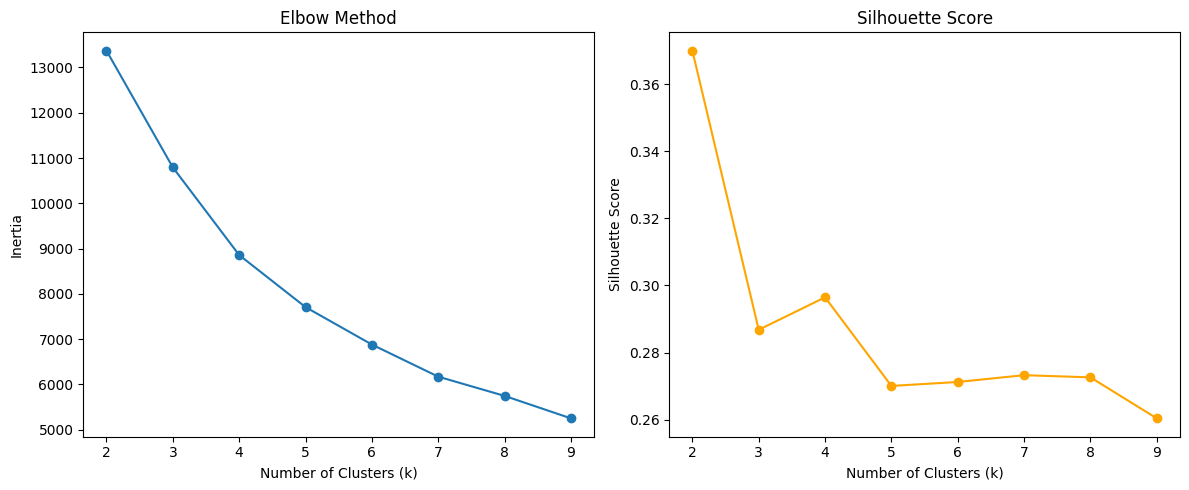

In [28]:
inertia = []
silhouette = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(customer_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(customer_scaled_df, kmeans.labels_))

# Plot both Elbow and Silhouette
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Elbow Method
ax[0].plot(K, inertia, 'o-')
ax[0].set_title('Elbow Method')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia')

# Silhouette Score
ax[1].plot(K, silhouette, 'o-', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


### Observations

- From the **Elbow Method**, the rate of decrease in inertia starts to slow after *k = 4*,  
  suggesting that additional clusters beyond this point add limited value.
- The **Silhouette Score** is highest at *k = 2*, but remains fairly stable up to *k = 4*,  
  indicating that these cluster counts offer reasonable structure and separation in the data.
- While *k = 2* gives the highest silhouette score, it likely oversimplifies customer diversity.  
  Using *k = 4* allows for more **meaningful behavioral segmentation** while keeping clusters distinct enough for business interpretation.

Hence, we proceed with **4 clusters** for our final model.

----------------------

## 11. Building the Clustering Model and Visualizing in PCA Space

Based on the previous analysis, we’ll proceed with **4 clusters** using the K-Means algorithm.  

K-Means is well-suited for this scenario because:
- Our features are now standardized and roughly symmetric.
- The goal is to group customers based on similarity in behavioral metrics.

To make the results easier to interpret visually, we’ll also use **Principal Component Analysis (PCA)**  
to reduce the data to two dimensions and plot how clusters are distributed in that space.


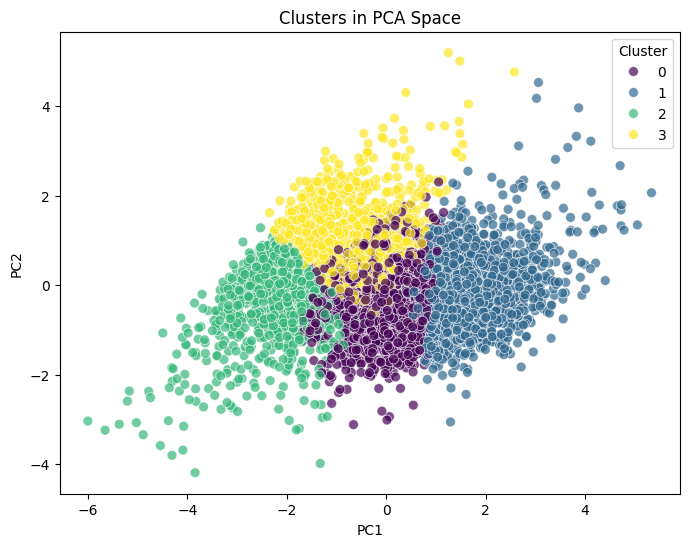

,PC1,PC2,Cluster
0,3.064361,4.525639,1
1,2.099169,0.229743,1
2,1.369863,0.833457,1
3,1.553823,0.943371,1
4,-1.385230,0.844785,3


In [29]:
# 1. Store the feature data for both PCA and K-Means
features = customer_scaled_df.copy() # Make a copy if necessary, or just use customer_scaled_df

# 2. Build K-Means model with 4 clusters and get predictions
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Added n_init for modern sklearn
cluster_labels = kmeans.fit_predict(features) # Fit and predict on original features

# 3. Perform PCA for 2D visualization on the ORIGINAL features
pca = PCA(n_components=2)
# pca_components should be based on the original data, NOT data that includes 'cluster'
pca_components = pca.fit_transform(features) 

# 4. Add PCA components and Cluster labels to a new dataframe
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels # Add the labels

# 5. Visualize clusters in PCA space
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('Clusters in PCA Space')
plt.show()

pca_df.head()

### Observations

The PCA plot shows a clear separation between most clusters, indicating that the K-Means algorithm  
successfully identified distinct patterns in customer behavior.

While some overlap is expected — since PCA only represents two dimensions out of four —  
the clusters still show **noticeable structure** rather than random dispersion.

This gives us confidence that the segmentation captures meaningful differences among customers.  
Next, we’ll interpret these clusters by comparing their average values across key features.


--------------

## 12. Cluster Profiling and Interpretation

Now that we have 4 clusters, the next step is to understand **what distinguishes each group of customers**.  
We’ll analyze the average values of key behavioral features —  
**Freshness**, **Total Orders**, **Total Spend**, and **Average Quantity** — for each cluster.

This helps us translate the clusters into meaningful customer segments that a business can act upon.


In [72]:
# Add cluster labels to the original (unscaled) customer dataset for interpretation
customer_metrics['Cluster'] = cluster_labels

In [53]:
# --- 1. Calculate Cluster Profiles ---
# We use the median to find the typical behavior of each cluster
cluster_profiles = customer_metrics.groupby('Cluster')[['freshness', 'total_orders', 'total_spent', 'average_quantity']].median()

# --- 2. Rank Clusters based on Business Value ---
# We rank clusters for each metric. 'ascending=False' means the highest value gets Rank 1.
# Since more is better for all your metrics, we rank them all the same way.
metric_ranks = cluster_profiles.rank(ascending=False)

# Create a Total Score by summing the ranks across all metrics
cluster_profiles['Total_Rank_Score'] = metric_ranks.sum(axis=1)

# --- 3. Create Stable Mapping ---
# Sort clusters by score (lowest score = highest performing group)
# We then use enumerate to assign IDs 0, 1, 2, and 3 in that order.
sorted_cluster_ids = cluster_profiles.sort_values('Total_Rank_Score').index
final_mapping = {raw_id: i for i, raw_id in enumerate(sorted_cluster_ids)}

# --- 4. Apply Mapping to Main Dataset ---
customer_metrics['Cluster'] = customer_metrics['Cluster'].map(final_mapping)

# --- 5. Display Clean Final Profiles ---
final_summary = (
    customer_metrics.groupby('Cluster')[['freshness', 'total_orders', 'total_spent', 'average_quantity']]
    .median()
    .round(2)
)
final_summary['Customer_Count'] = customer_metrics.groupby('Cluster').size()

print("Final Segment Profiles (0=Loyal, 1=Developing, 2=Bulk, 3=Dormant):")
display(final_summary)

Final Segment Profiles (0=Loyal, 1=Developing, 2=Bulk, 3=Dormant):


,freshness,total_orders,total_spent,average_quantity,Customer_Count
Cluster,,,,,
0,711.0,10.0,3444.86,220.42,1880
1,689.0,3.0,656.99,135.00,1762
2,326.0,2.0,664.16,208.33,1193
3,320.0,1.0,162.45,60.00,1017


### Cluster Profiling and Business Insights

| Cluster | Freshness | Total Orders | Total Spend | Avg Quantity | Interpretation |
|----------|------------|--------------|--------------|---------------|----------------|
| **0** | 711.0	 | 10.0 | 3444.86 | 220.42 | **Loyal High-Value Customers** – Recently active, purchase frequently, and spend the most. These are the business’s most valuable customers who should be prioritized for retention and loyalty programs. |
| **1** | 689.0 | 3.0 | 656.99 | 135.00 | **New / Developing Customers** – Fairly recent purchasers with few orders and low spend. They represent customers in early engagement stages who can be nurtured through personalized offers. |
| **2** | 326.0 | 2.0 | 664.16 | 208.33 | **Dormant or At-Risk Customers** – Haven’t purchased recently and contribute minimally to revenue. They may require win-back campaigns or could be de-prioritized. |
| **3** | 320.0 | 1.0 | 162.45 | 60.00 | **Bulk Buyers (At Risk)** – Older purchases but with very high order sizes, likely wholesale or bulk clients who have become inactive. Focused reactivation campaigns could yield strong returns. |

<hr style="height: 0.5px; border: none; background-color: #A9A9A9;">

### Summary

The clustering reveals four distinct behavioral groups:
1. **Cluster 0** – Loyal high-value customers driving the majority of revenue.  
2. **Cluster 1** – Developing customers with growth potential.  
3. **Cluster 2** – Dormant and low-value customers requiring reactivation or minimal focus.  
4. **Cluster 3** – Bulk buyers who were once active but may have shifted away.

This segmentation allows the business to design **targeted strategies** —  
such as retention incentives for Cluster 0, upselling campaigns for Cluster 1,  
and personalized win-back offers for Cluster 3 —  
while minimizing marketing spend on Cluster 2.


---

## 13. Project Summary & Business Recommendations

### Summary of Work

This analysis aimed to segment online retail customers based on their purchasing behavior to help the business make data-driven marketing decisions.  
Starting from raw transaction data, we cleaned and transformed it into customer-level insights, focusing on four behavioral dimensions: **Freshness**, **Total Orders**, **Total Spend**, and **Average Quantity**.

Through exploratory analysis, we observed that all features were heavily right-skewed, dominated by a few high-value customers.  
After applying the **Yeo–Johnson transformation** and **Standard Scaling**, the data became more balanced, allowing for fair comparison across variables.  

Using K-Means clustering and validating potential cluster counts with the **Elbow** and **Silhouette** methods,  
we finalized **4 clusters** that represented meaningful and interpretable customer segments.  
The results were further confirmed with PCA visualization, showing clear structural separation among groups.

<hr style="height: 0.5px; border: none; background-color: #A9A9A9;">

### Key Insights

| Segment | Description | Strategic Focus |
|----------|--------------|----------------|
| **Cluster 0 – Loyal High-Value** | Most recent and frequent buyers who spend the most. | Maintain loyalty with exclusive offers, priority service, and rewards programs. |
| **Cluster 1 – Developing Customers** | Recently acquired, moderate interest, low spending. | Targeted onboarding campaigns and personalized discounts to encourage repeat purchases. |
| **Cluster 2 – Dormant / Low-Value** | Inactive customers with low order history and spending. | Low-cost reactivation campaigns, or deprioritize in marketing budget allocation. |
| **Cluster 3 – Bulk Buyers (At Risk)** | Large-order customers who haven’t purchased recently. | Personalized win-back or account reactivation efforts focusing on high-value deals. |


<hr style="height: 0.5px; border: none; background-color: #A9A9A9;">

### Business Impact

This segmentation provides a **data-driven foundation** for customer relationship management and marketing optimization.  
By focusing on high-value and developing segments while efficiently managing dormant ones,  
the business can improve customer retention, reduce acquisition costs, and increase overall profitability.

The methodology can be refreshed periodically (e.g., quarterly) as new customer data accumulates,  
ensuring that the segmentation remains dynamic and reflects changing customer behavior.


---

## 14. Next Steps

While the current clustering provides strong and interpretable customer segments, there are several opportunities to refine and extend the analysis:

1. **Model Validation Over Time** –  
   Re-run the clustering quarterly to see if customer movement between segments reveals changes in buying behavior or loyalty trends.

2. **Alternative Clustering Algorithms** –  
   Experiment with models like **K-Medoids**, **Gaussian Mixture Models (GMM)**, or **DBSCAN** to test whether more flexible distance metrics or density-based methods improve separation.

3. **Feature Enrichment** –  
   Incorporate additional behavioral and demographic attributes such as average inter-purchase time, product category diversity, or customer location for deeper insights.

4. **Action Tracking** –  
   Evaluate business outcomes (e.g., repeat purchase rate, campaign response) by cluster to measure the impact of targeted marketing strategies.

These steps can help the business evolve from static segmentation to **dynamic customer lifecycle management**, where marketing actions are continuously informed by real behavior patterns.


In [ ]:
# customer_metrics = customer_metrics.reset_index()

In [ ]:
# customer_metrics.to_sql('customer_segments', engine, if_exists='replace', index=False)

852